In [615]:
# import necessary libraries and functions

import pandas as pd
import seaborn as sns
import time
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# create data path shortcut
DATA = "/Users/kaitlynfreeley/Desktop/DM_Files/hw1/iris"

In [616]:
# input data from the iris.data file

iris_labeled = pd.read_csv(f"{DATA}/iris.data",header=None,names=["sepal_length", "sepal_width", "petal_length", "petal_width", "class"])

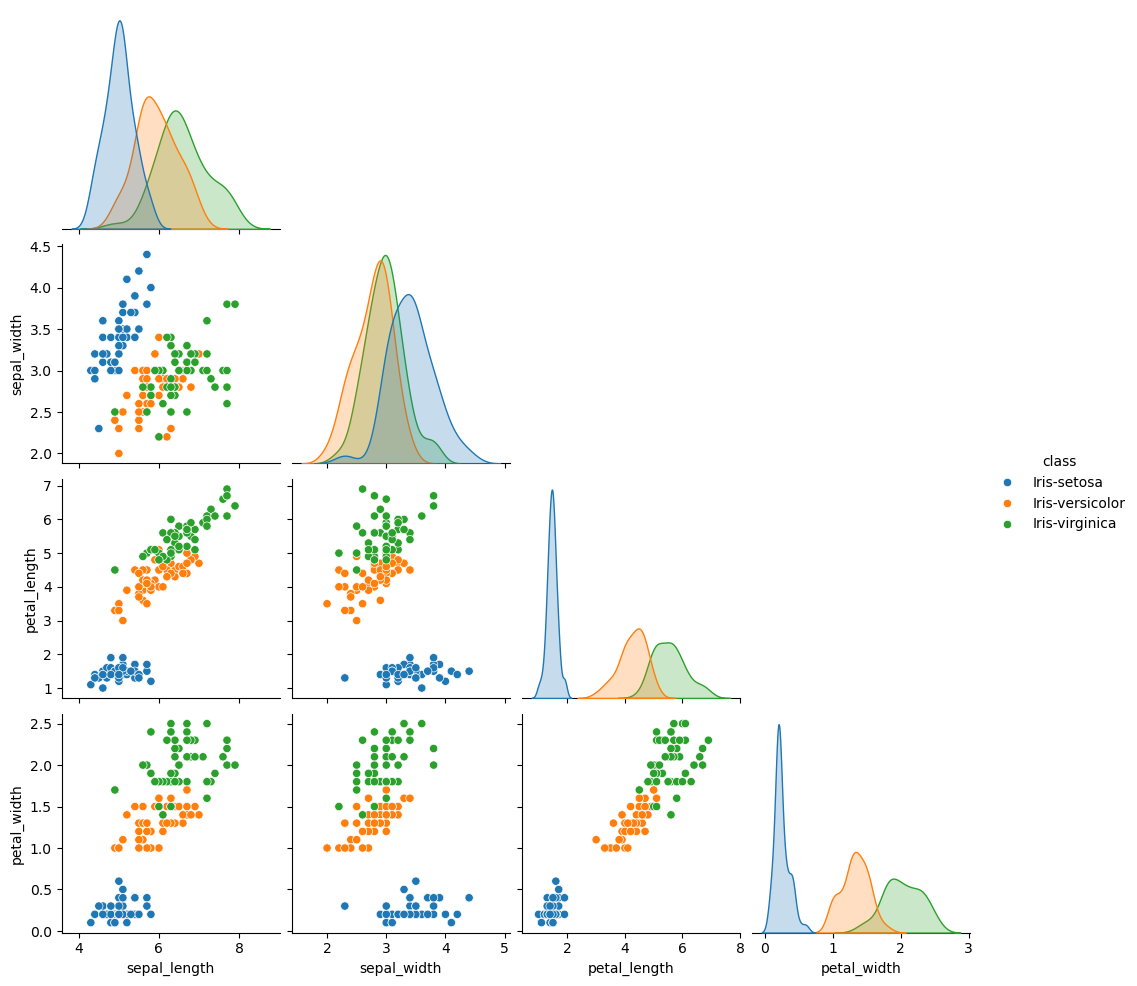

In [617]:
# scatter plots between each numerical variable in the iris dataframe to show their relationships 
# with distribution plots on the diagonal for each variable and each class

sns.pairplot(iris_labeled, hue = "class", corner = True)

In [618]:
# split dataframe into "X" and "Y" dataframes to prepare for train test split

iris_X = iris_labeled[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
iris_y = iris_labeled[["class"]]

In [619]:
# split data for train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    iris_X, iris_y, test_size=0.20, random_state=42, stratify=iris_y
)

# y_train and y_test are currently of size (120, 1), need them to be (120, ), so convert them to an array and ravel:

y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

In [620]:
# standardize the data to have a mean of 0 and scale the data to have a standard deviation of 1

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [621]:
# train the logisitic regression model using the training set
# also use time library as a timer for running time for training

start_time = time.time()
model = LogisticRegression().fit(X_train, y_train)
train_time = time.time() - start_time

In [622]:
# evaluate the model on the train set, using accuracy as evaluation metric
# also use time library as a timer for running time for testing

start_time = time.time()
y_train_pred = model.predict(X_train)
test_time = time.time() - start_time 

accuracy_train = accuracy_score(y_train, y_train_pred)

# evaluate the model on the test set, using accuracy as evaluation metric

y_test_pred = model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_test_pred)

In [623]:
# print the accuracies for the train and test sets, rounding to 4 decimal points

print(f"Train Accuracy: {accuracy_train:.4f}, Test Accuracy: {accuracy_test:.4f}")

Train Accuracy: 0.9583, Test Accuracy: 0.9333


For the test data, the model has an accuracy of 0.9333. So it can predict the correct category 93.33% of the time.

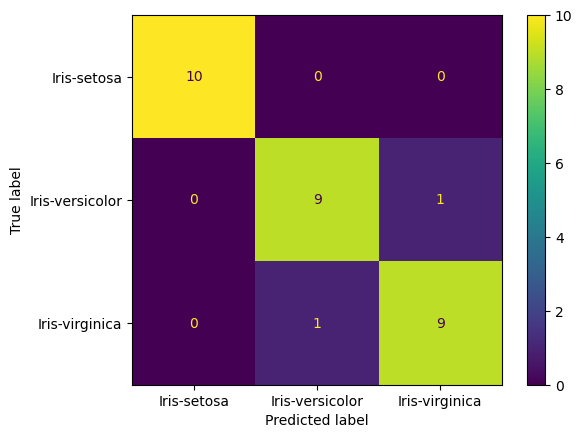

In [625]:
# output the confusion matrix to see how well the model did in classifying the flowers
# using ConfusionMatrixDisplay from sklearn to make it fancy with labels

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=model.classes_)
plt.show()

From the confusion matrix, we can see that for the test set the model correctly predicted Iris-setosa 10 times, Iris-versicolor 9 times, and Iris-virginica 9 times. Once it predicted Iris-versicolor when it was actually Iris-virginica, and one other time it predicted Iris-virginica when it was really Iris-versicolor. Overall, the model seems to do very well on this test set, as seen by its accuracy of 0.9333.

In [627]:
print(f"Running time for training : {train_time:.4f}, Running time for testing: {test_time:.4f}")

Running time for training : 0.0014, Running time for testing: 0.0001


In [628]:
# versions for requirements.txt
print(pd.__version__)
print(sklearn.__version__)
print(sns.__version__)

2.2.2
1.5.1
0.13.2
